CT Slice Shape: (256, 256)
Mask Shape: (256, 256)


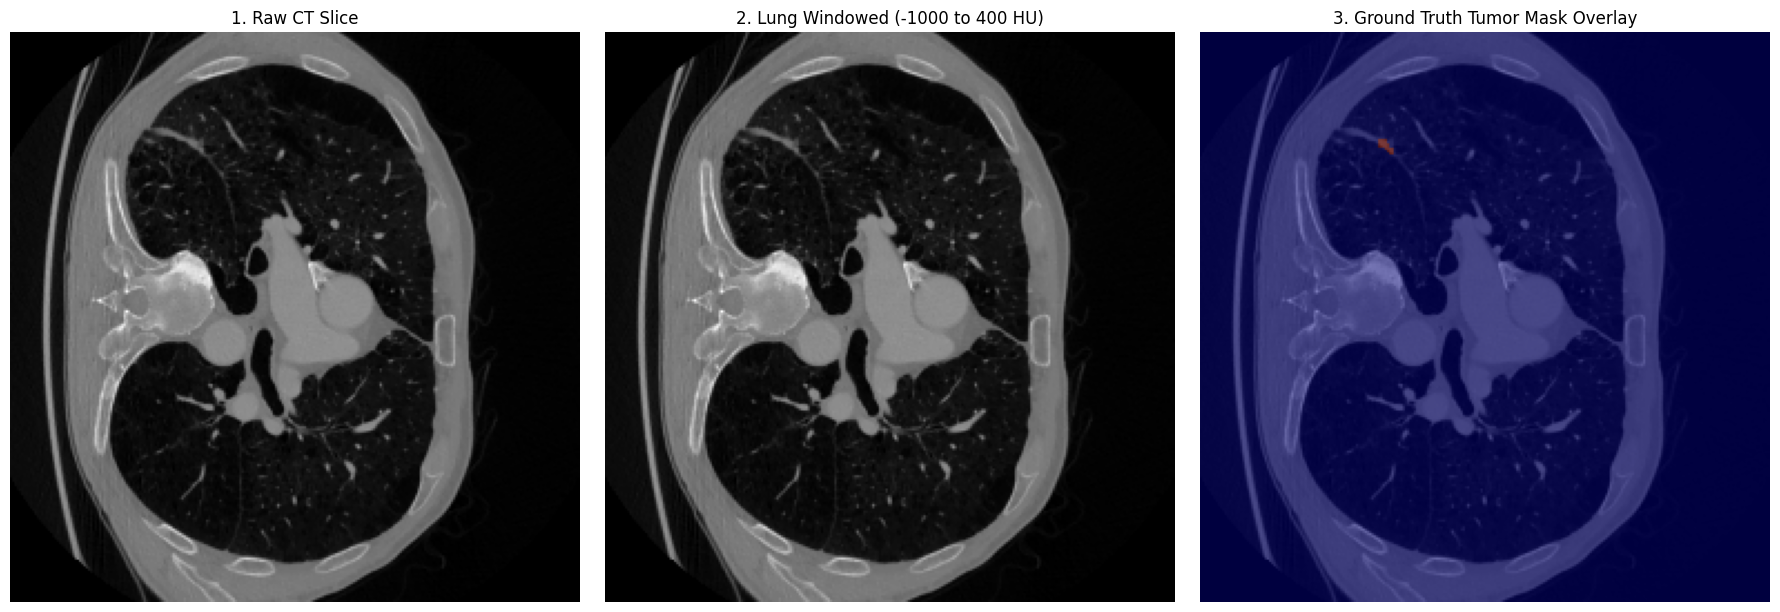

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the paths based on your current folder structure
# We are grabbing slice number 7 from Patient 0
image_path = '../data/raw/train/0/data/304.npy'
mask_path = '../data/raw/train/0/masks/304.npy'

# 2. Load the 2D NumPy arrays directly into memory
raw_slice = np.load(image_path)
mask_slice = np.load(mask_path)

print(f"CT Slice Shape: {raw_slice.shape}")
print(f"Mask Shape: {mask_slice.shape}")

# 3. DIGITAL IMAGE PROCESSING: The Lung Window
# Lungs are mostly air (-1000 HU). We clip the pixels to only show 
# tissue between -1000 and 400 HU. This mathematically erases the bones.
lung_windowed_slice = np.clip(raw_slice, -1000, 400)

# 4. Visualize the Data Pipeline End-to-End
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(raw_slice, cmap='gray')
axes[0].set_title("1. Raw CT Slice")
axes[0].axis('off')

axes[1].imshow(lung_windowed_slice, cmap='gray')
axes[1].set_title("2. Lung Windowed (-1000 to 400 HU)")
axes[1].axis('off')

# Display the mask over the windowed image using a heat map color (jet)
axes[2].imshow(lung_windowed_slice, cmap='gray')
axes[2].imshow(mask_slice, cmap='jet', alpha=0.5) # alpha makes it semi-transparent
axes[2].set_title("3. Ground Truth Tumor Mask Overlay")
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [13]:
import os
import numpy as np

masks_folder = '../data/raw/train/0/masks/'
print("Scanning Patient 0 for tumors...")

tumor_slices = []
for filename in sorted(os.listdir(masks_folder)):
    # Load just the mask
    mask = np.load(os.path.join(masks_folder, filename))
    
    # If the mask has any pixels greater than 0, it contains a tumor!
    if np.max(mask) > 0:
        tumor_slices.append(filename)

print(f"Tumor found on these slices: {tumor_slices}")

Scanning Patient 0 for tumors...
Tumor found on these slices: ['304.npy', '305.npy', '306.npy', '307.npy', '308.npy', '309.npy', '310.npy', '311.npy', '312.npy', '313.npy', '314.npy', '315.npy', '316.npy', '317.npy', '318.npy', '319.npy', '320.npy', '321.npy', '322.npy', '323.npy', '324.npy', '325.npy', '326.npy', '327.npy', '328.npy', '329.npy', '330.npy', '331.npy', '332.npy', '333.npy', '334.npy', '335.npy', '336.npy', '337.npy', '338.npy', '339.npy', '340.npy', '341.npy', '342.npy', '343.npy', '344.npy', '345.npy', '346.npy', '347.npy', '348.npy', '349.npy', '350.npy', '351.npy', '352.npy', '353.npy', '354.npy', '355.npy', '356.npy', '357.npy', '358.npy', '359.npy', '360.npy', '361.npy', '362.npy', '363.npy', '364.npy', '365.npy', '366.npy', '367.npy', '368.npy', '369.npy', '370.npy', '371.npy', '372.npy', '373.npy']


In [12]:
import os
import numpy as np

train_folder = '../data/raw/train/'
print("Scanning ALL patients for tumors...")
print("-" * 40)

# Loop through every patient folder (0, 1, 2, etc.)
# We use a custom sort so '10' comes after '2', not after '1'
patient_folders = sorted([d for d in os.listdir(train_folder) if d.isdigit()], key=int)

for patient_id in patient_folders:
    masks_folder = os.path.join(train_folder, patient_id, 'masks')
    
    # Skip if the masks folder doesn't exist for some reason
    if not os.path.exists(masks_folder):
        continue
        
    tumor_slices = []
    
    # Scan every slice for this patient
    for filename in sorted(os.listdir(masks_folder)):
        mask = np.load(os.path.join(masks_folder, filename))
        if np.max(mask) > 0:
            tumor_slices.append(filename)
            
    # Print the results
    if len(tumor_slices) > 0:
        print(f"🚨 Patient {patient_id}: Tumor FOUND on {len(tumor_slices)} slices!")
        print(f"   -> Try viewing slice: {tumor_slices[0]}")
    else:
        print(f"✅ Patient {patient_id}: Healthy (No tumors)")

print("-" * 40)
print("Scan Complete.")

Scanning ALL patients for tumors...
----------------------------------------
🚨 Patient 0: Tumor FOUND on 70 slices!
   -> Try viewing slice: 304.npy
🚨 Patient 1: Tumor FOUND on 21 slices!
   -> Try viewing slice: 491.npy
🚨 Patient 2: Tumor FOUND on 10 slices!
   -> Try viewing slice: 118.npy


KeyboardInterrupt: 

In [7]:
# import nibabel as nib
# import matplotlib.pyplot as plt
# import numpy as np

# # 1. Define the paths to a single patient's scan and their matching mask
# image_path = '../data/raw/imagesTr/lung_001.nii.gz'
# mask_path = '../data/raw/labelsTr/lung_001.nii.gz'

# # 2. Load the 3D volumes into memory
# img_volume = nib.load(image_path).get_fdata()
# mask_volume = nib.load(mask_path).get_fdata()

# print(f"CT Scan Shape: {img_volume.shape}")
# print(f"Mask Shape: {mask_volume.shape}")

# # 3. Grab a 2D slice right from the middle of the chest
# slice_idx = img_volume.shape[2] // 2 

# raw_slice = img_volume[:, :, slice_idx]
# mask_slice = mask_volume[:, :, slice_idx]

# # 4. DIGITAL IMAGE PROCESSING: The Lung Window
# # Lungs are mostly air (-1000 HU). We clip the pixels to only show 
# # tissue between -1000 and 400 HU. This erases the dense white bones!
# lung_windowed_slice = np.clip(raw_slice, -1000, 400)

# # 5. Visualize the Data Pipeline End-to-End
# fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# axes[0].imshow(raw_slice, cmap='gray')
# axes[0].set_title("1. Raw CT Slice (Bones too bright)")
# axes[0].axis('off')

# axes[1].imshow(lung_windowed_slice, cmap='gray')
# axes[1].set_title("2. Lung Windowed (-1000 to 400 HU)")
# axes[1].axis('off')

# # Display the mask over the windowed image
# axes[2].imshow(lung_windowed_slice, cmap='gray')
# axes[2].imshow(mask_slice, cmap='jet', alpha=0.5) # alpha makes it semi-transparent
# axes[2].set_title("3. Ground Truth Tumor Mask Overlay")
# axes[2].axis('off')

# plt.tight_layout()
# plt.show()